In [1]:
# Cell 1: Setup
import sys, os, torch
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join('..')))
from load_dataset import load_cybhi_dataset
from run import *
from models import DeepECG, ResNet1D
from visualizations import Visualizer
import warnings
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Framework loaded. Running on {device}")

Framework loaded. Running on cpu


In [2]:
# --- TASKS 1-3: Random Split (Base) ---
print("Loading CYBHi (Long-Term Subset 'A0') for Random Split...")

# We use 'long-term' as the default base for random splitting
loader = load_cybhi_dataset(num_beats=3, subset='long-term', cleanup_zip=False)
x_all, y_all = loader.load_all_sessions()

print(f"Data Loaded: {x_all.shape} samples, {len(np.unique(y_all))} subjects")

# Run Standard Benchmarks
print("\n=== TASK 1: Closed-Set Identification ===")
run_closed_set_identification(x_all, y_all, DeepECG, epochs=3, device=device)

print("\n=== TASK 2: Verification ===")
run_verification(x_all, y_all, DeepECG, epochs=3, device=device)

print("\n=== TASK 3: Subject-Disjoint Verification ===")
run_subject_disjoint_verification(x_all, y_all, DeepECG, epochs=3, device=device)

Loading CYBHi (Long-Term Subset 'A0') for Random Split...


Processing signals: 100%|██████████| 63/63 [02:24<00:00,  2.30s/it]


Data Loaded: (21628, 600) samples, 63 subjects

=== TASK 1: Closed-Set Identification ===

[TASK] Closed-Set Identification on cpu
    Epoch 001 | Loss: 3.3520
    Epoch 002 | Loss: 2.2517
    Epoch 003 | Loss: 1.8851
[RESULT] Closed-Set Accuracy: 0.3558

=== TASK 2: Verification ===

[TASK] Verification (Random Split / Closed-Set) on cpu
[INFO] Phase 1: Training feature extractor (Learning Identity)...
    Epoch 001 | Loss: 3.4581
    Epoch 002 | Loss: 2.4062
    Epoch 003 | Loss: 1.9973
[INFO] Phase 2: Computing EER using 'balanced' sampling...
[INFO] Generating 10000 BALANCED pairs (50/50 split)...
[RESULT] Mode: BALANCED | EER: 0.2104 | AUC: 0.8739

=== TASK 3: Subject-Disjoint Verification ===

[TASK] Subject-Disjoint Verification (Open-Set) on cpu
[INFO] Splitting: 44 Training Subjects vs 19 Test Subjects
[INFO] Phase 1: Training on Known Subjects...
    Epoch 001 | Loss: 3.0434
    Epoch 002 | Loss: 1.9256
    Epoch 003 | Loss: 1.5472
[INFO] Phase 2: Computing EER on 19 Unseen S

{'eer': 0.2091999999999995, 'auc': 0.8682903599999999}

In [4]:
# --- TASK 4: Biometric Regimes Evaluation ---
print("\n=== TASK 4: Biometric Regimes ===")

# A. SHORT-TERM & STATE ROBUSTNESS (Folder: CI-A1-A2)
# Row 1: Session 1 (First Half) -> Session 2 (Second Half)
# Since subjects only have 1 file, this tests robustness to task changes within that file.
print("\n[A] Loading Short-Term / State Robustness (CI-A1-A2)...")
loader_st = load_cybhi_dataset(num_beats=3, subset='short-term', cleanup_zip=False)
x_st_enr, y_st_enr = loader_st.load_session("Session_1")
x_st_prb, y_st_prb = loader_st.load_session("Session_2")

print(f"    Short-Term Shapes: Enroll {x_st_enr.shape}, Probe {x_st_prb.shape}")
print("    Running Verification...")
# run_cross_session_verification(x_st_enr, y_st_enr, x_st_prb, y_st_prb, DeepECG, epochs=15, device=device, visualize=False)


# B. LONG-TERM STABILITY (Folder: A0)
# Row 2: Visit 1 (T1) -> Visit 2 (T2, ~3 months later)
print("\n[B] Loading Long-Term Stability (A0)...")
loader_lt = load_cybhi_dataset(num_beats=3, subset='long-term', cleanup_zip=False)
x_lt_enr, y_lt_enr = loader_lt.load_session("Session_1")
x_lt_prb, y_lt_prb = loader_lt.load_session("Session_2")

print(f"    Long-Term Shapes: Enroll {x_lt_enr.shape}, Probe {x_lt_prb.shape}")
print("    Running Verification...")
# run_cross_session_verification(x_lt_enr, y_lt_enr, x_lt_prb, y_lt_prb, DeepECG, epochs=15, device=device, visualize=True)


=== TASK 4: Biometric Regimes ===

[A] Loading Short-Term / State Robustness (CI-A1-A2)...


Processing Session_2: 100%|██████████| 66/66 [02:08<00:00,  1.94s/it]


    Short-Term Shapes: Enroll (3365, 600), Probe (3580, 600)
    Running Verification...

[B] Loading Long-Term Stability (A0)...


Processing Session_2: 100%|██████████| 63/63 [01:03<00:00,  1.01s/it]

    Long-Term Shapes: Enroll (11192, 600), Probe (10436, 600)
    Running Verification...



=== TASK 5: Blind Segmentation (Long-Term Subset) ===


Processing Session_2: 100%|██████████| 63/63 [00:00<00:00, 148.99it/s]


Blind Data Shapes: Enroll (3846, 5000), Probe (3869, 5000)

[Blind] Identification

[TASK] Cross-Session Identification (Rank-1) on cpu
[INFO] Subjects: 63 in Train, 63 in Test.
[INFO] Evaluated on intersection: 63 common subjects.
[INFO] Phase 1: Training Classifier on Session 1...
    Epoch 001 | Loss: 4.0544
    Epoch 002 | Loss: 3.5748
[INFO] Phase 2: Predicting on Session 2...
[RESULT] Cross-Session Identification Accuracy: 7.24%

[Blind] Verification

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 4.0544
    Epoch 002 | Loss: 3.5748
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.3570 | AUC: 0.7004
[INFO] Computing T-SNE... this may take a moment.


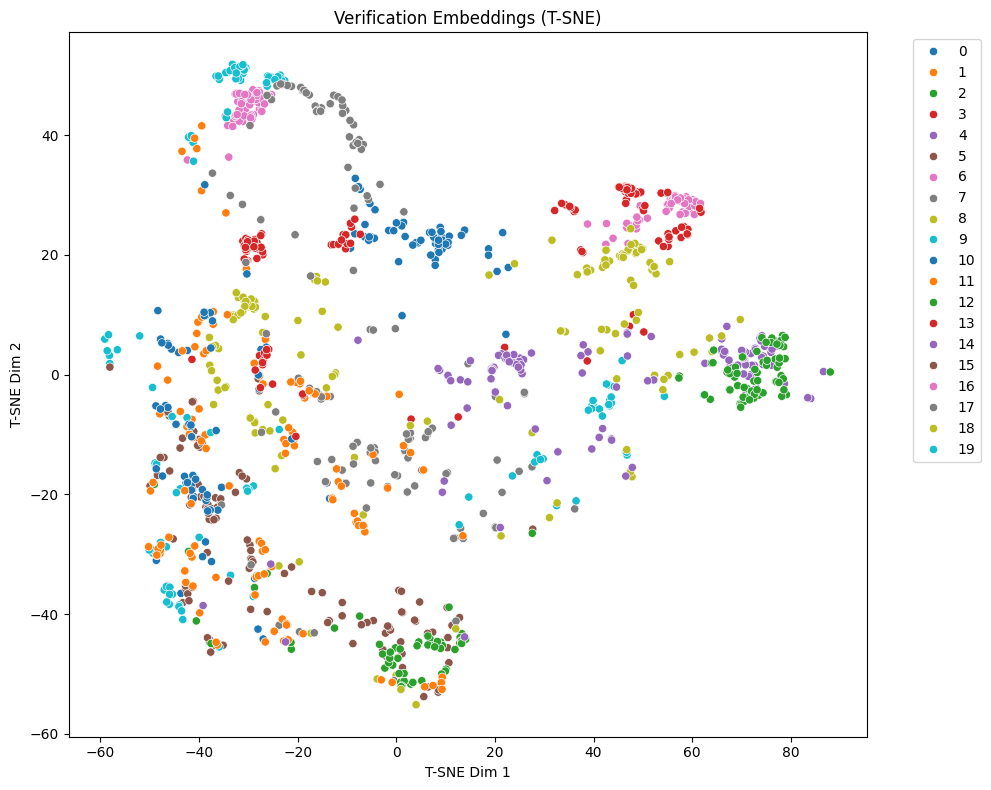

{'eer': 0.35699999999944315, 'auc': 0.70039324}

In [5]:
# --- TASK 5: Blind Segmentation (Long-Term) ---
print("\n=== TASK 5: Blind Segmentation (Long-Term Subset) ===")

blind_params = {
    'mode': 'blind',
    'window_len': 5.0,  
    'stride': 2.0,      
    'bandpass': True,
    'normalize': 'zscore'
}

# Load Long-Term subset (A0) with Blind Mode
loader_blind = load_cybhi_dataset(
    num_beats=1, 
    subset='long-term', 
    preprocessing_params=blind_params, 
    cleanup_zip=False
)

x_blind_enr, y_blind_enr = loader_blind.load_session("Session_1")
x_blind_prb, y_blind_prb = loader_blind.load_session("Session_2")

print(f"Blind Data Shapes: Enroll {x_blind_enr.shape}, Probe {x_blind_prb.shape}")

print("\n[Blind] Identification")
run_cross_session_identification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=2, device=device)

print("\n[Blind] Verification")
run_cross_session_verification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=2, device=device, visualize=True)